<a href="https://colab.research.google.com/github/diogenesjusto/FIAP/blob/master/MBAIA/14DTSR_Aula4_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. carga de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.seasonal import seasonal_decompose


# 2. carga de dados
df = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/refs/heads/master/Gradua%C3%A7%C3%A3o/dados/base_transacional_supermercado.csv")

# Antes de realizar a modelagem de uma série temporal, precisamos realizar a agregação adequada
# A base acima é um dataset "trasancional"

In [ ]:
# Mais numerical features sobre dataaset de PIB
df = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/master/SHIFT/Data/pib.csv")
df

,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi3,PIBi4,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03,100.00
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03
2,3,mar/04,110.43,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70
3,4,abr/04,106.77,95.36,118.34,100.49,94.58,123.55,101.02,91.79,...,103.09,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17
4,5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,...,102.05,103.09,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,134,fev/15,144.42,147.35,133.73,143.57,147.81,148.96,147.54,157.30,...,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.92
134,135,mar/15,151.68,149.64,163.27,152.09,154.87,179.07,159.56,147.28,...,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44
135,136,abr/15,147.03,153.81,149.93,152.28,161.21,164.74,161.16,162.21,...,149.51,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92
136,137,mai/15,148.94,149.66,153.03,149.82,157.03,169.39,158.76,149.06,...,144.42,149.51,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49


In [ ]:
# Acrescentando estatísticas móveis a série temporal
df['PIB_MA6'] = df['PIB'].rolling(6).mean()

In [ ]:
df[['PIB', 'PIB_MA6']]

,PIB,PIB_MA6
0,103.09,NaN
1,102.05,NaN
2,110.43,NaN
3,106.77,NaN
4,108.08,NaN
...,...,...
133,144.42,151.130000
134,151.68,150.736667
135,147.03,149.133333
136,148.94,148.713333


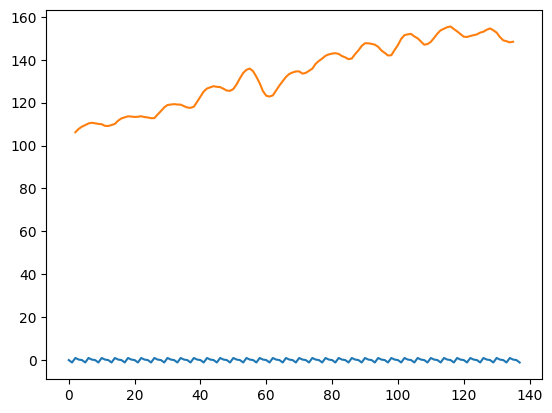

In [ ]:
# Decomposição de uma série temporal
df_seasonal = seasonal_decompose(df["PIB"], period=4)

plt.plot(df_seasonal.seasonal)

plt.plot(df_seasonal.trend)
#plt.plot(df_seasonal.seasonal)

In [ ]:
# Preenchimento de valores nulos para S.T.
df.at[2, 'PIB']=np.nan
df.at[3, 'PIB']=np.nan
df

,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12,PIBt,PIBinterpolated
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,102.59,102.24,99.96,101.93,101.17,101.70,100.03,100.00,103.09,103.090
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03,102.05,102.050
2,3,mar/04,NaN,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,110.43,110.430
3,4,abr/04,NaN,95.36,118.34,100.49,94.58,123.55,101.02,91.79,...,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,110.43,109.255
4,5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,...,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,108.08,108.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,134,fev/15,144.42,147.35,133.73,143.57,147.81,148.96,147.54,157.30,...,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.92,144.42,144.420
134,135,mar/15,151.68,149.64,163.27,152.09,154.87,179.07,159.56,147.28,...,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44,151.68,151.680
135,136,abr/15,147.03,153.81,149.93,152.28,161.21,164.74,161.16,162.21,...,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,147.03,147.030
136,137,mai/15,148.94,149.66,153.03,149.82,157.03,169.39,158.76,149.06,...,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,148.94,148.940


In [ ]:
# Preenchimeto de valores nulos com pandas: preenchendo os valores nulos com o último valor válido anterior
df['PIBt'] = df['PIB'].fillna(method='ffill')
df

/tmp/ipykernel_11551/3767533201.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['PIBt'] = df['PIB'].fillna(method='ffill')


,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12,PIBt,PIBinterpolated
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,102.59,102.24,99.96,101.93,101.17,101.70,100.03,100.00,103.09,103.090
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03,102.05,102.050
2,3,mar/04,NaN,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,102.05,110.430
3,4,abr/04,NaN,95.36,118.34,100.49,94.58,123.55,101.02,91.79,...,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,102.05,109.255
4,5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,...,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,108.08,108.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,134,fev/15,144.42,147.35,133.73,143.57,147.81,148.96,147.54,157.30,...,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.92,144.42,144.420
134,135,mar/15,151.68,149.64,163.27,152.09,154.87,179.07,159.56,147.28,...,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44,151.68,151.680
135,136,abr/15,147.03,153.81,149.93,152.28,161.21,164.74,161.16,162.21,...,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,147.03,147.030
136,137,mai/15,148.94,149.66,153.03,149.82,157.03,169.39,158.76,149.06,...,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,148.94,148.940


In [ ]:
# Método de preenchimento por interpolação: de forma resumida, é uma "emenda" na série que tenta realizar o melhor ajuste
df.at[3, 'PIB']=np.nan
df['PIBinterpolated'] = df['PIB'].interpolate()
df

,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12,PIBt,PIBinterpolated
0,1,jan/04,103.09,109.19,108.67,109.08,102.84,114.27,105.38,127.49,...,102.59,102.24,99.96,101.93,101.17,101.70,100.03,100.00,103.09,103.090
1,2,fev/04,102.05,95.65,104.52,97.63,90.76,109.83,94.99,96.60,...,104.52,102.59,102.24,99.96,101.93,101.17,101.70,100.03,102.05,102.050
2,3,mar/04,110.43,91.69,125.53,99.26,89.78,133.24,99.43,83.79,...,106.27,104.52,102.59,102.24,99.96,101.93,101.17,101.70,110.43,110.430
3,4,abr/04,NaN,95.36,118.34,100.49,94.58,123.55,101.02,91.79,...,104.10,106.27,104.52,102.59,102.24,99.96,101.93,101.17,110.43,109.255
4,5,mai/04,108.08,92.47,121.49,98.96,91.34,128.32,99.55,85.73,...,103.91,104.10,106.27,104.52,102.59,102.24,99.96,101.93,108.08,108.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,134,fev/15,144.42,147.35,133.73,143.57,147.81,148.96,147.54,157.30,...,154.04,154.75,154.34,148.92,154.49,150.92,151.44,148.92,144.42,144.420
134,135,mar/15,151.68,149.64,163.27,152.09,154.87,179.07,159.56,147.28,...,156.65,154.04,154.75,154.34,148.92,154.49,150.92,151.44,151.68,151.680
135,136,abr/15,147.03,153.81,149.93,152.28,161.21,164.74,161.16,162.21,...,151.46,156.65,154.04,154.75,154.34,148.92,154.49,150.92,147.03,147.030
136,137,mai/15,148.94,149.66,153.03,149.82,157.03,169.39,158.76,149.06,...,150.70,151.46,156.65,154.04,154.75,154.34,148.92,154.49,148.94,148.940


# Feature Importance

1. Análise de coeficientes (técnicas de regressão)

In [ ]:
treino = df.iloc[0:132]
teste = df.iloc[132:138]
#4. Regressão Linear
Y_treino = treino.iloc[:,[2]]

X = ['BRP','BRL'] # RLM, exógena BRP, BRL

X_treino = treino.loc[:,X]

mod = LinearRegression()
mod.fit(X = X_treino, y = Y_treino)

# Modelo => Y = a1*x1 + a2*x2 + b
# Abaixo coeficientes angulares, isto é, a1 e a2 (BRP e BRL, respectivamente)

print(mod.coef_) # coef angular

[[0.59210438 0.23984646]]


Assumindo coeficiente de BRP sendo 0.59, se aumentarmos em 1 unidade o índice do tráfego BRP, o que acontece com o PIB?

Teremos um aumento de 0.59. De forma semelhante, aumento de 1 unidade do índice BRL, tem impacto de 0.23 no PIB.

In [ ]:
#X = ['SPP','SLP', 'RJP','RJL','PRP','PRL' ] # RLM, exógena BRP, BRL
X = [ 'RJP','PRP','PRL' ]

X_treino = treino.loc[:,X]

mod = LinearRegression()
mod.fit(X = X_treino, y = Y_treino)

# Modelo => Y = a1*x1 + a2*x2 + b
# Abaixo coeficientes angulares, isto é, a1 e a2 (BRP e BRL, respectivamente)

print(mod.coef_) # coef angular

[[0.80430041 0.13624605 0.05194582]]


2. Análise de importância de variáveis "decision split" (aplicável para árvores)

In [ ]:
# Presente na implementação do algo. Random Forest
from sklearn.ensemble import RandomForestRegressor

modRF = RandomForestRegressor()
modRF.fit(X_treino, Y_treino)

print(modRF.feature_importances_, modRF.feature_names_in_)

[0.4661029  0.0402141  0.45486067 0.01143907 0.022046   0.00533727] ['SPP' 'SLP' 'RJP' 'RJL' 'PRP' 'PRL']


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


<Axes: >

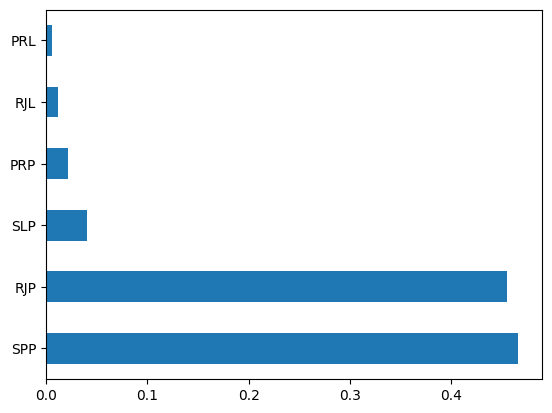

In [ ]:
# Visualização Gráfica
feature_importance = pd.Series(modRF.feature_importances_, index=modRF.feature_names_in_)
feature_importance.nlargest(6).plot(kind='barh')

3. Permutação

<BarContainer object of 3 artists>

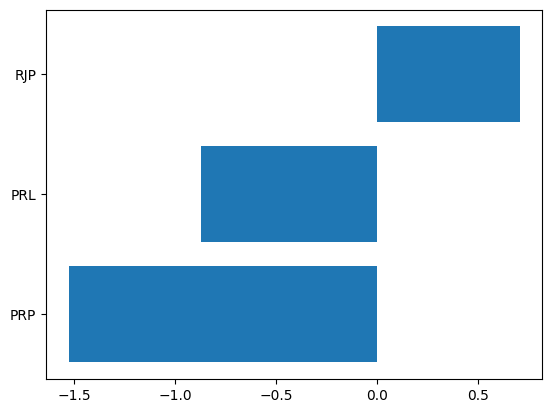

In [ ]:
from sklearn.inspection import permutation_importance

X_teste = teste.loc[:,X]

Y_teste = teste.iloc[:,[2]]

#
perm_importance = permutation_importance(mod, X_teste, Y_teste, n_repeats=200)
# Ordem-Idx é um vetor de ordenação indicial, de acordo com a métrica de importância das features
ordem_idx = perm_importance.importances_mean.argsort()
plt.barh(X_teste.columns[ordem_idx], perm_importance.importances_mean[ordem_idx])

# DISCRETIZAÇÃO

Variável contínua: sem "buracos", por exemplo, números reais

Variável discreta: com alguns "buracos intervalados", naturais

Por exemplo: faixas de valores, faixas etárias, faixas de renda, etc

<Axes: >

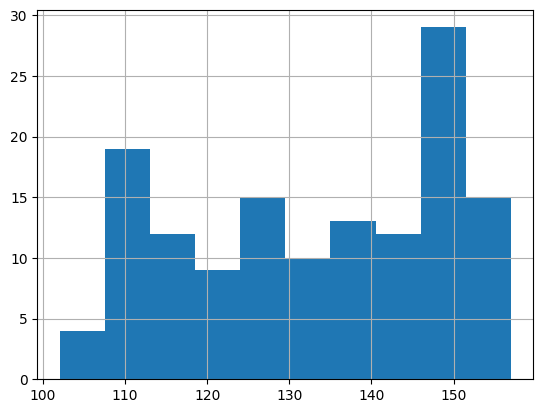

In [ ]:
df['PIB'].hist()

In [ ]:
# 1.o caso: discretização de largura fixa
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.3 MB/s eta 0:00:00


In [ ]:
from feature_engine.discretisation import EqualWidthDiscretiser

discEW  = EqualWidthDiscretiser(bins=4, variables=['PIB'])
discEW.fit(df)
df_transf = discEW.transform(df)
df_transf.groupby('PIB').count()

,Unnamed: 0,ANO_MES,BRL,BRP,BRT,SLP,SPP,SPT,PRL,PRP,...,PIBi3,PIBi4,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12
PIB,,,,,,,,,,,,,,,,,,,,,
0,28,28,28,28,28,28,28,28,28,28,...,28,28,28,28,28,28,28,28,28,28
1,31,31,31,31,31,31,31,31,31,31,...,31,31,31,31,31,31,31,31,31,31
2,31,31,31,31,31,31,31,31,31,31,...,31,31,31,31,31,31,31,31,31,31
3,48,48,48,48,48,48,48,48,48,48,...,48,48,48,48,48,48,48,48,48,48


In [ ]:
# 2.o caso: discretização de mesma quantidade por categoria (ou faixa)
from sklearn.preprocessing import KBinsDiscretizer

discKB = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
discKB.fit(df[['PIB']])

df_transf2 = discKB.transform(df[['PIB']])

df['PIB_Discretized'] = df_transf2


df.groupby('PIB_Discretized').count()

,Unnamed: 0,ANO_MES,PIB,BRL,BRP,BRT,SLP,SPP,SPT,PRL,...,PIBi3,PIBi4,PIBi5,PIBi6,PIBi7,PIBi8,PIBi9,PIBi10,PIBi11,PIBi12
PIB_Discretized,,,,,,,,,,,,,,,,,,,,,
0.0,35,35,35,35,35,35,35,35,35,35,...,35,35,35,35,35,35,35,35,35,35
1.0,34,34,34,34,34,34,34,34,34,34,...,34,34,34,34,34,34,34,34,34,34
2.0,34,34,34,34,34,34,34,34,34,34,...,34,34,34,34,34,34,34,34,34,34
3.0,35,35,35,35,35,35,35,35,35,35,...,35,35,35,35,35,35,35,35,35,35
